[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_07/Taller/MISIS4825_Laboratorio07_Taller.ipynb)

# Laboratorio 07 - Taller: Fundamentos de Machine Learning y Redes Neuronales

## Introducción

En este taller exploraremos el uso de TensorFlow y Keras para el diseño y entrenamiento de redes neuronales perceptrón multicapa. Utilizaremos el conjunto de datos **Pizza or not pizza?** para construir un modelo capaz de clasificar imágenes de acuerdo a su clase.

## Contenido del Taller

1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

## Datos

[Pizza or not pizza?](https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza)

In [1]:
# librerías
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import json
import kagglehub
from PIL import Image
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random


1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

In [2]:
path = kagglehub.dataset_download("carlosrunner/pizza-not-pizza")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pizza-not-pizza' dataset.
Path to dataset files: /kaggle/input/pizza-not-pizza


Antes de transformar los datos, exploramos los contenidos del dataset.

In [3]:
# path con las imagenes
base_path = os.path.join(path, 'pizza_not_pizza')

# iterar por cada subcarpeta
for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    # si es una carpeta, ver cuantos archivos tiene
    if os.path.isdir(category_path):
        num_files = len(os.listdir(category_path))
        print(f"Carpeta '{category}': {num_files} archivos")

Carpeta 'not_pizza': 983 archivos
Carpeta 'pizza': 983 archivos


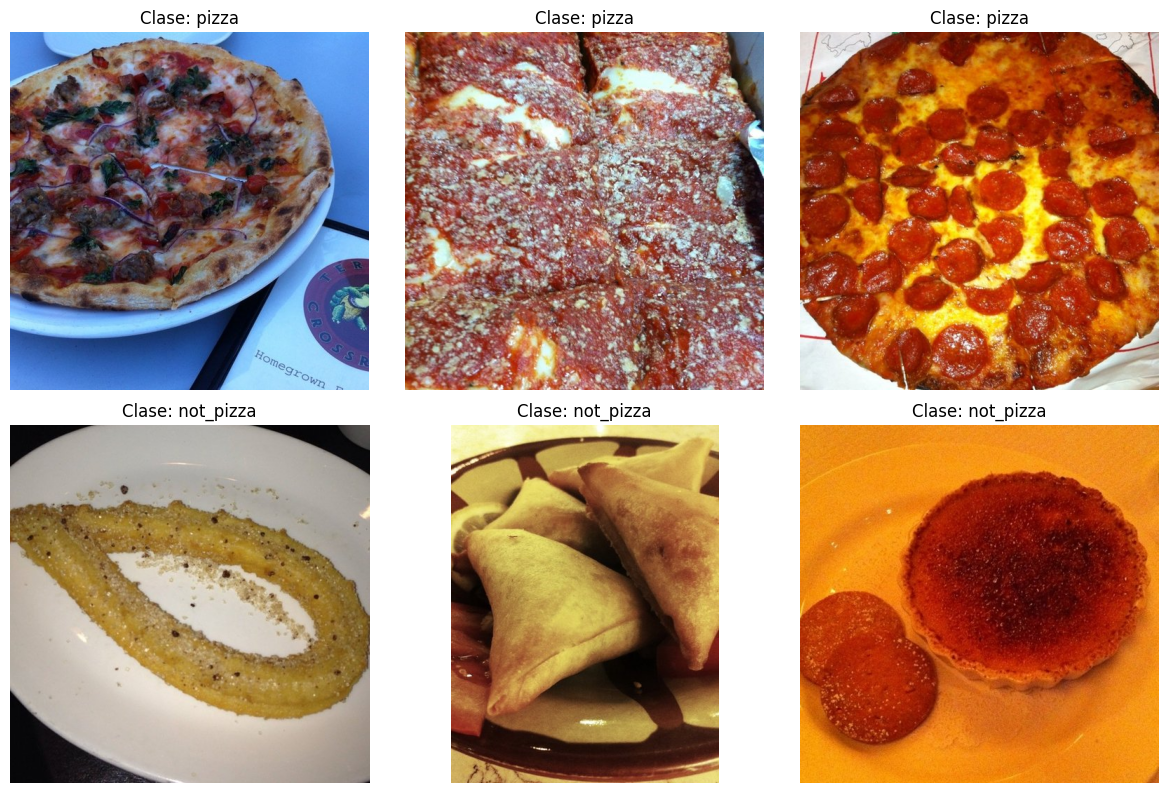

In [4]:
# configurar una semilla
random.seed(26)

base_path = os.path.join(path, 'pizza_not_pizza')
categories = ['pizza', 'not_pizza']

# configurar la figura
plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    category_path = os.path.join(base_path, category)

    # elegir tres imagenes al azar por cada categoría
    all_images = os.listdir(category_path)
    selected_images = random.sample(all_images, 3)

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(category_path, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(img)
        plt.title(f"Clase: {category}")
        plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# crear un dataframe con el path de la imagen y su categoría respectiva
data = []
for category in categories:
    category_path = os.path.join(base_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        data.append({'filepath': img_path, 'label': category})

df_pizza_not_pizza = pd.DataFrame(data)
df_pizza_not_pizza.head()

,filepath,label
0,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
1,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
2,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
3,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
4,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza


In [6]:
# separamos los datos en train, val y test
train_df, test_val_df = train_test_split(df_pizza_not_pizza, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(df_pizza_not_pizza))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


El preprocesamiento se configuró mediante ImageDataGenerator aplicando las siguientes técnicas para optimizar el entrenamiento:

- Normalización: Escala los píxeles de [0-255] a $[0, 1]$ con el fin de facilitar la convergencia del gradiente descendente, evitando que los pesos de la red oscilen y acelerando el aprendizaje.

- Estandarización: resta la media y divide entre la desviación estandar. Transforma los datos para que tengan media 0 y varianza 1, lo que asegura que todas las características (píxeles) tengan el mismo peso estadístico. Esto previene que el modelo se sesgue por rangos de color dominantes y estabiliza el proceso de optimización.

- Data Augmentation (rotación, zoom, desplazamientos): Genera variaciones aleatorias de las imágenes originales de forma que se reduzca el overfitting del modelo, pues lo fuerza a reconocer patrones estructurales importar su posición o ángulo.

- Ajuste de Brillo (brightness_range): Simula diferentes condiciones lumínicas, desde fotos oscuras hasta con flash. Esto se hace debido a que al observar un par de imágenes de ejemplo, es notorio que tienen sombras o zonas oscuras. Esto aumenta la robustez del modelo, evitando que confunda la falta de luz o sombras fuertes con características propias de alguna clase.

- Redimensionamiento: Estandariza todas las imágenes a una dimensión común (100x100) para que la arquitectura de la red pueda procesar los datos en lotes (batches) de forma computacionalmente eficiente.

In [7]:
def preprocesamiento(img):
    # 1. Aseguramos que la entrada sea tratable (Keras suele enviar float32 0-255)
    img_uint8 = img.astype("uint8")

    # 2. Aumentar saturación
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV).astype("float32")
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.3, 0, 255)

    # 3. Volver a RGB
    img_rgb = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2RGB)

    # 4. Aplicar el Blur
    img_blurred = cv2.GaussianBlur(img_rgb, (3, 3), 0)

    # CLAVE: Devolver como float32 para que el rescale=1./255 no falle
    return img_rgb.astype("float32")

In [8]:
# configuración del data generator
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    # preprocessing_function=preprocesamiento,
    rescale=1./255, # normalización
    # samplewise_center=True,
    # samplewise_std_normalization=True,
    rotation_range=25, # rotación: rota aleatoriamente las imágenes hasta 30 grados.
    zoom_range=0.2, # zoom: acerca o aleja la imagen aleatoriamente un 20%.
    horizontal_flip=True, # volteo horizontal: invierte la imagen como un espejo.
    # fill_mode="constant",
    # brightness_range=[0.5, 1.2] # cambio de brillo: varía la exposición para manejar imágenes oscuras o con mucho flash.
)

# para train normalizar y estandarizar con la media y desviación estandar de las imagenes de train
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    # preprocessing_function=preprocesamiento,
    rescale=1./255,
    # samplewise_center=True,
    # samplewise_std_normalization=True,
)

# ajustar
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


In [9]:
train_gen.class_indices

{'not_pizza': 0, 'pizza': 1}

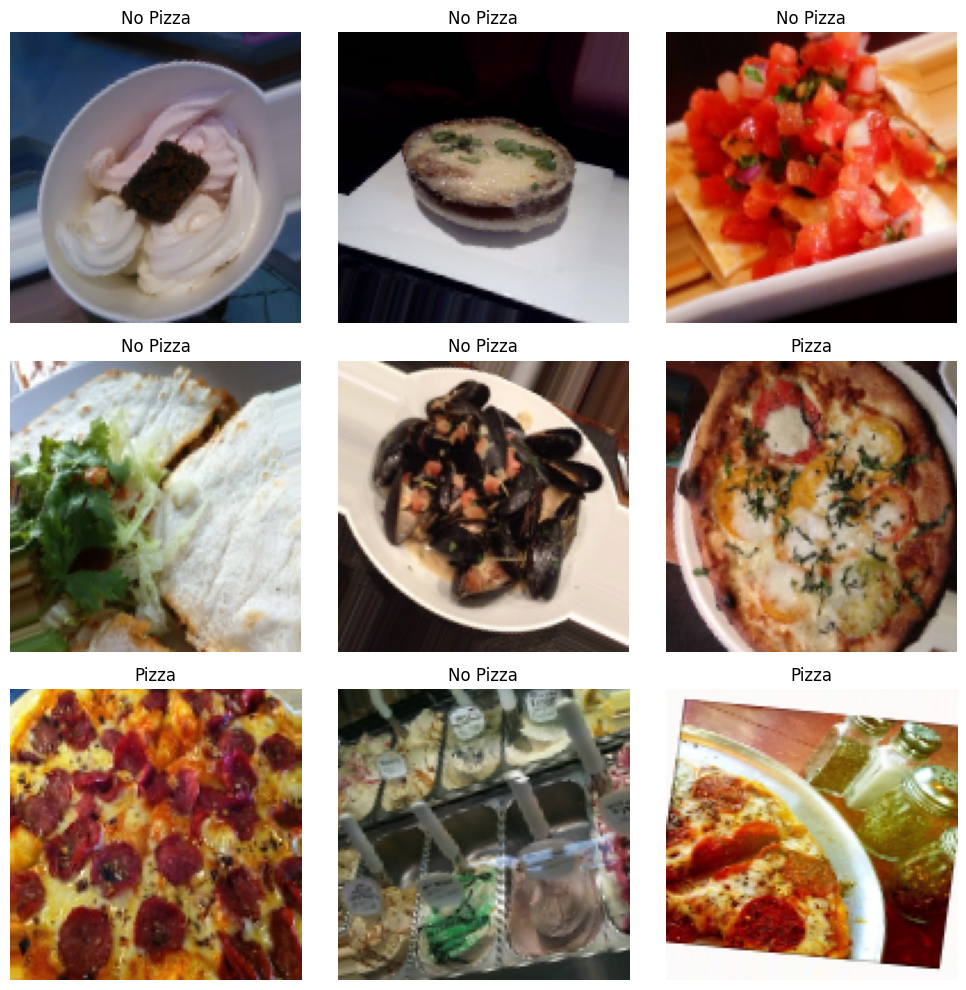

In [10]:
# se toma un batch de entrenamiento con las transformaciones
images, labels = next(train_gen)

# visualizar 9 imagenes
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    # Ahora image_to_show ya debería estar en un rango [0, 1] decente
    image_to_show = images[i]

    plt.imshow(image_to_show)
    label = "Pizza" if labels[i] == 1 else "No Pizza"
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

A continuación realizamos la definición del modelo perceptrón multicapa utilizando Keras. El modelo cuenta con la sigueinte arquitectura:
- Flatten: inicialmente, se aplana la imagen de entrada. Esta imagen está representada como tres matrices (tres canales) de tamaño 100x100.
- Capas densas: se crean tres capas densas con función de activación relu, con 512, 256 y 124 neuronas respectivamente, de forma que la entrada sea representada en dimensiones mayores de forma que el modelo aprenda representaciones que ayuden la clasificación de estas mismas.
- Dropout: entre cada capa densa y la siguiente se aplica un dropout de forma que el modelo generalice mejor.
- Capa de salida: la capa de salida contará con una neurona con función de activación sigmoide, pues se está tratando con un problema de clasificación binaria.

In [11]:
# definicion del modelo
model = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
# resumen del modelo
model.summary()

# compilar el modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,625,921 (48.16 MB)

 Trainable params: 12,625,153 (48.16 MB)

 Non-trainable params: 768 (3.00 KB)

Como se puede observar con el resumen del modelo, hay un total de 15,523,833 parametros entrenables.

3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

- ModelCheckpoint: la función del ModelCheckpoint es guardar el modelo automáticamente cada vez que se registra una mejora, en este caso, en la pérdida del conjunto de validación, o en otras palabras, un nuevo mínimo den val_loss. Esto garantiza que, si el entrenamiento se interrumpe o el modelo empieza a empeorar al final, siempre conservaremos el archivo con los mejores pesos encontrados en el entrenamiento.

- EarlyStopping: se utiliza para identificar overfitting. Si la métrica de la validación deja de mejorar durante cierto número de épocas, en este caso 10, el entrenamiento se detiene automáticamente. Al configurar restore_best_weights=True, el modelo final recupera los pesos de su mejor época, evitando que el resultado sea una versión degradada por el exceso de entrenamiento.

- ReduceLROnPlateau: ayuda a evitar un entrenamiento insuficiente cuando el modelo se estanca en una "meseta" de aprendizaje. Si tras 5 épocas no hay mejora, reduce la tasa de aprendizaje (Learning Rate) por un factor de 0.2. Esto permite que el optimizador realice ajustes más pequeños y precisos para encontrar el mínimo global de la función de pérdida que antes no alcanzaba.

In [12]:
# checkpoint del modelo
model_checkpoint = ModelCheckpoint('best_model.h5',
                                   save_best_only=True,
                                   monitor='val_loss',
                                   mode='min')

# early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=15,
                               verbose=1,
                               restore_best_weights=True,
                               mode='min')

# reducción del lr
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.1,
                              patience=5,
                              verbose=1,
                              min_lr=1e-6,
                              mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.6182 - loss: 0.7449

43/43 ━━━━━━━━━━━━━━━━━━━━ 32s 668ms/step - accuracy: 0.6163 - loss: 0.7277 - val_accuracy: 0.6574 - val_loss: 0.7008 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 461ms/step - accuracy: 0.6156 - loss: 0.6817 - val_accuracy: 0.5558 - val_loss: 1.0415 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.6537 - loss: 0.6227

43/43 ━━━━━━━━━━━━━━━━━━━━ 23s 531ms/step - accuracy: 0.6403 - loss: 0.6470 - val_accuracy: 0.6574 - val_loss: 0.6358 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 513ms/step - accuracy: 0.6417 - loss: 0.6375 - val_accuracy: 0.6371 - val_loss: 0.6506 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 462ms/step - accuracy: 0.6504 - loss: 0.6451 - val_accuracy: 0.6574 - val_loss: 0.6552 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.6736 - loss: 0.6037

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 495ms/step - accuracy: 0.6730 - loss: 0.6048 - val_accuracy: 0.6980 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6849 - loss: 0.6041

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 486ms/step - accuracy: 0.6860 - loss: 0.6043 - val_accuracy: 0.7208 - val_loss: 0.5868 - learning_rate: 0.0010
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 460ms/step - accuracy: 0.6642 - loss: 0.6254 - val_accuracy: 0.6396 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 487ms/step - accuracy: 0.6679 - loss: 0.6087 - val_accuracy: 0.6853 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 457ms/step - accuracy: 0.6868 - loss: 0.6018 - val_accuracy: 0.6421 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 485ms/step - accuracy: 0.6919 - loss: 0.5959 - val_accuracy: 0.6726 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 12/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6664 - loss: 0.5999
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 458ms/step - accuracy: 0.6635 - loss: 0.6122 - v

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 470ms/step - accuracy: 0.7064 - loss: 0.5740 - val_accuracy: 0.7259 - val_loss: 0.5796 - learning_rate: 1.0000e-04
Epoch 16/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.6942 - loss: 0.5680

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 487ms/step - accuracy: 0.6984 - loss: 0.5740 - val_accuracy: 0.7310 - val_loss: 0.5771 - learning_rate: 1.0000e-04
Epoch 17/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 32s 742ms/step - accuracy: 0.7013 - loss: 0.5754 - val_accuracy: 0.7208 - val_loss: 0.5772 - learning_rate: 1.0000e-04
Epoch 18/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 467ms/step - accuracy: 0.6977 - loss: 0.5754 - val_accuracy: 0.7183 - val_loss: 0.5803 - learning_rate: 1.0000e-04
Epoch 19/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 492ms/step - accuracy: 0.7071 - loss: 0.5727 - val_accuracy: 0.7234 - val_loss: 0.5782 - learning_rate: 1.0000e-04
Epoch 20/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 486ms/step - accuracy: 0.6948 - loss: 0.5807 - val_accuracy: 0.7284 - val_loss: 0.5790 - learning_rate: 1.0000e-04
Epoch 21/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7088 - loss: 0.5596
Epoch 21: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 462ms/step - accuracy: 0.6

4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

Para la compilación y entrenamiento del modelo, se utilizará como optimizador adam, como función de pérdida binary_crossentropy, pues se está tratando con un problema de clasificación binario (pizza o no), y como métrica de monitoreo se utilizará el accuracy.

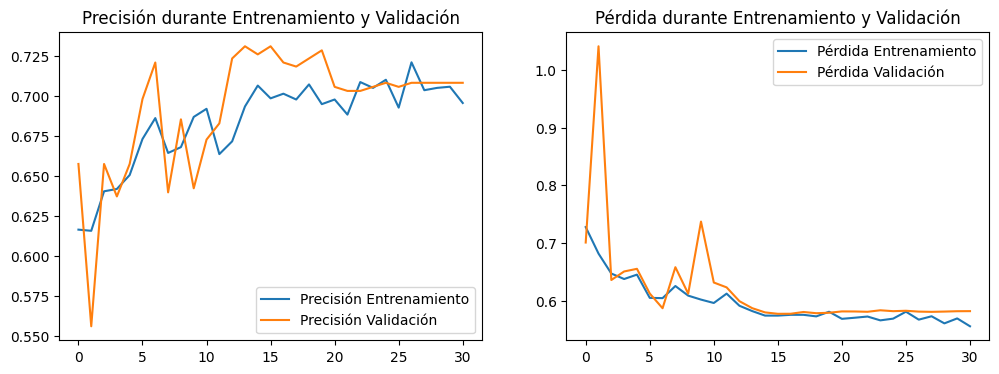

In [13]:
# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step


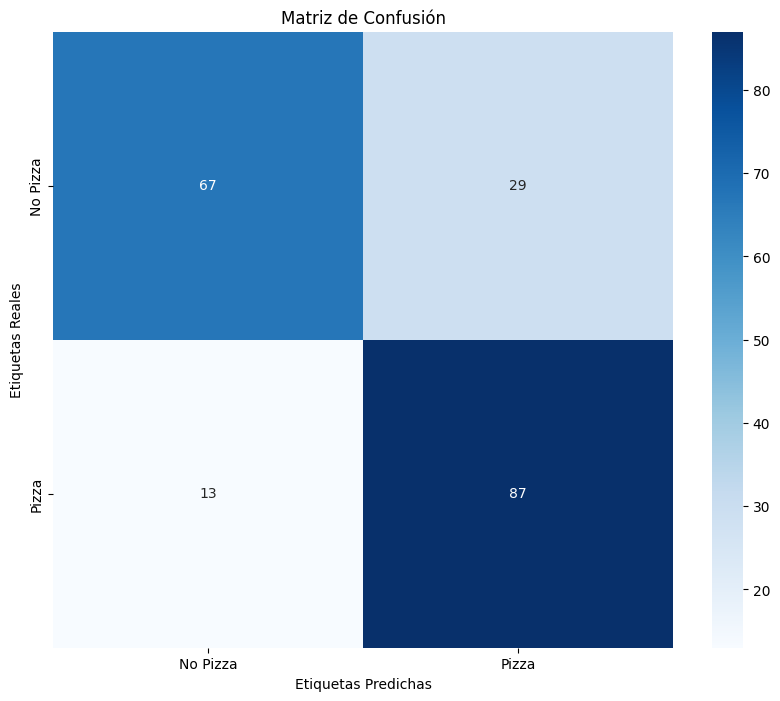

              precision    recall  f1-score   support

    No Pizza       0.84      0.70      0.76        96
       Pizza       0.75      0.87      0.81       100

    accuracy                           0.79       196
   macro avg       0.79      0.78      0.78       196
weighted avg       0.79      0.79      0.78       196



In [14]:
# cargar el mejor modelo
best_model = load_model('best_model.h5')
labels = ['No Pizza', 'Pizza']

# evaluación en conjunto de test
test_gen.reset()
predictions = best_model.predict(test_gen, verbose=1)
y_pred = (predictions > 0.5).astype("int32").flatten()
y_test = test_gen.classes

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

# reporte de clasificación
print(classification_report(y_test, y_pred, target_names=labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


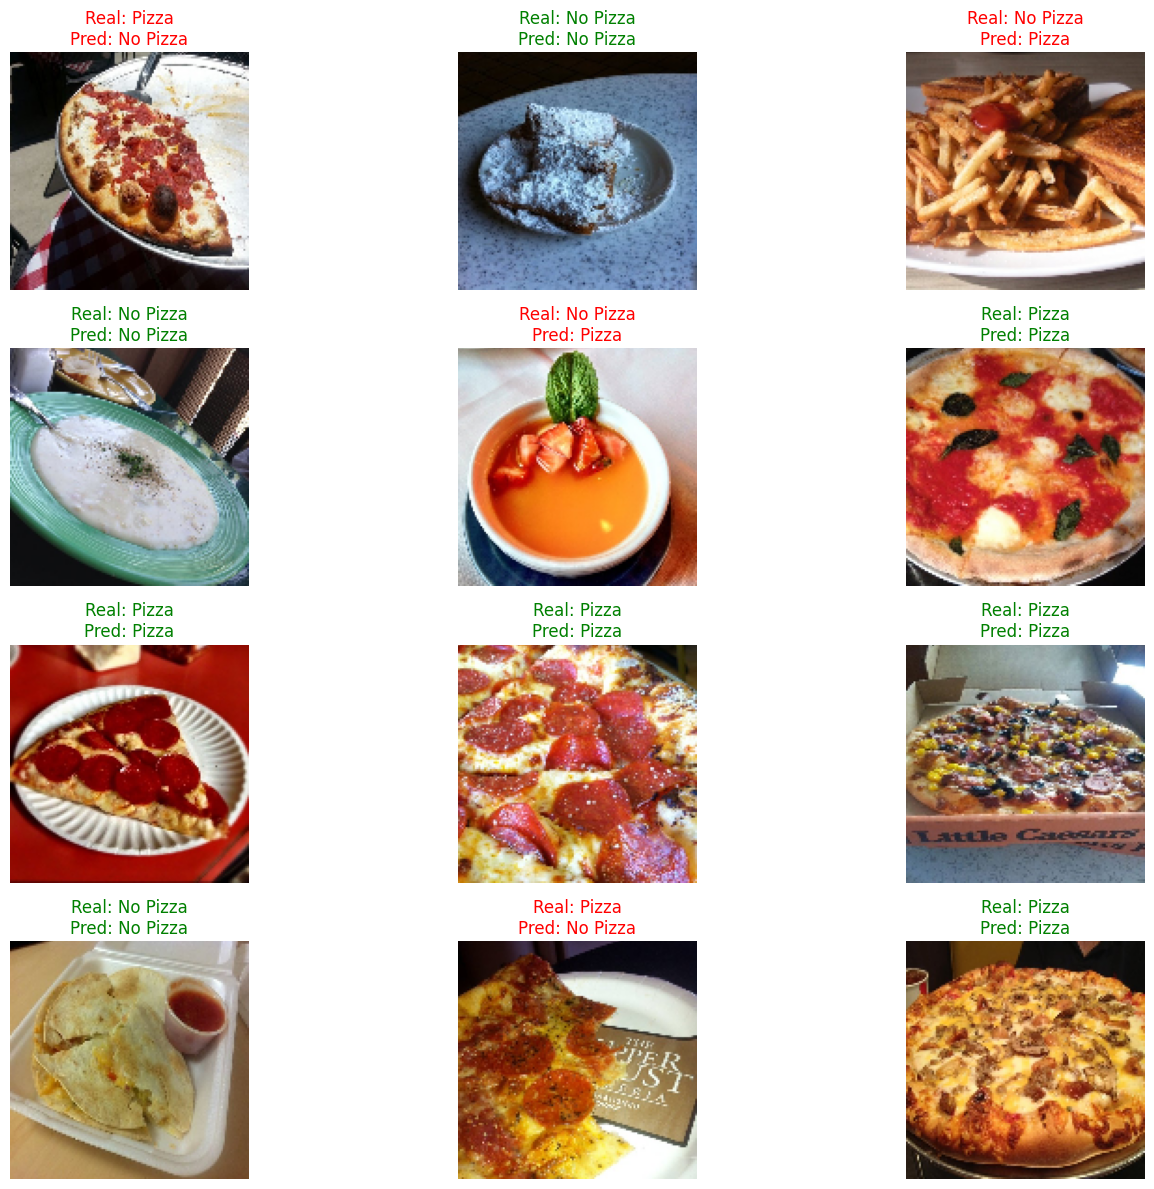

In [15]:

# 1. Obtener un batch de imágenes y etiquetas del generador de test
# Importante: No uses shuffle en test_gen para que coincidan con y_pred
test_gen.reset()
x_test_batch, y_test_batch = next(test_gen)

# 2. Hacer predicciones sobre ese batch específico
batch_preds = best_model.predict(x_test_batch)
batch_y_pred = (batch_preds > 0.5).astype("int32").flatten()

# 3. Graficar
plt.figure(figsize=(15, 12))
for i in range(12): # Vamos a ver 12 imágenes
    plt.subplot(4, 3, i + 1)

    # Si usaste normalización (0-1), imshow las detecta bien
    # Si usaste samplewise_center, recuerda la normalización min-max para verlas
    img = x_test_batch[i]
    if img.min() < 0 or img.max() > 1:
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)

    plt.imshow(img)

    # Comparar real vs predicho
    actual = labels[int(y_test_batch[i])]
    pred = labels[batch_y_pred[i]]

    # Color verde si es correcto, rojo si falló
    color = 'green' if actual == pred else 'red'

    plt.title(f"Real: {actual}\nPred: {pred}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()